In [ ]:
%matplotlib inline 
%matplotlib widget

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import traveltime as tt
from pygimli.viewer.pv import drawSensors,drawSlice
from pygimli.physics import TravelTimeManager, Refraction

import numpy as np
import datetime
import matplotlib.pylab as plt
from sgt_file_generator import read_sgt_file

In [2]:
pg.setLogLevel(0)

kw = dict(cMin=200, 
          cMax=500, 
          cMap="Spectral_r", 
          coverage=1,
          xlabel="x (m)", 
          ylabel="z (m)", 
          showMesh=True)

kw2 = dict(cMin=200, 
           cMax=500, 
           cMap="Spectral_r", 
           coverage=1,
           xlabel="x (m)", 
           ylabel="z (m)")

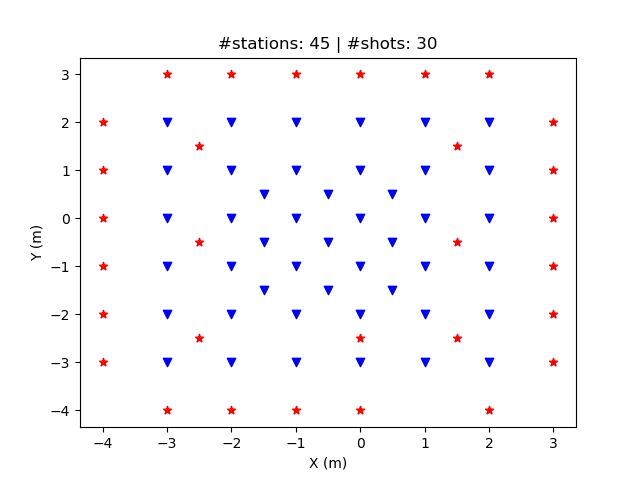

In [3]:
# coordinates, travel_times = read_sgt_file('/Users/mary/Documents/Codes/Saintsomology/3D-Saints/archive_tests/example_multiple_shots.sgt')
coordinates, travel_times = read_sgt_file('saintsmology_corrected.sgt')

plt.figure()

stations = np.array([])
sources = np.array([])

for i in range(len(travel_times)):
    
    indx_station = travel_times [i][0]
    indx_shot = travel_times [i][1]
    ttime = travel_times [i][2]

    stations = np.append(stations, [coordinates[indx_station][0], coordinates[indx_station][1]])
    sources = np.append(sources, [coordinates[indx_shot][0], coordinates[indx_shot][1]])

stations = np.unique(stations.reshape(-1,2), axis=0)
sources = np.unique(sources.reshape(-1,2), axis=0)

plt.scatter(stations[:,0], stations[:,1], c='blue', marker='v')
plt.scatter(sources[:,0], sources[:,1], c='red', marker='*')


plt.title(f'#stations: {len(stations)} | #shots: {len(sources)}')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')

plt.show()


Data: Sensors: 75 data: 428, nonzero entries: ['g', 's', 't', 'valid']


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x17dcd1310>)

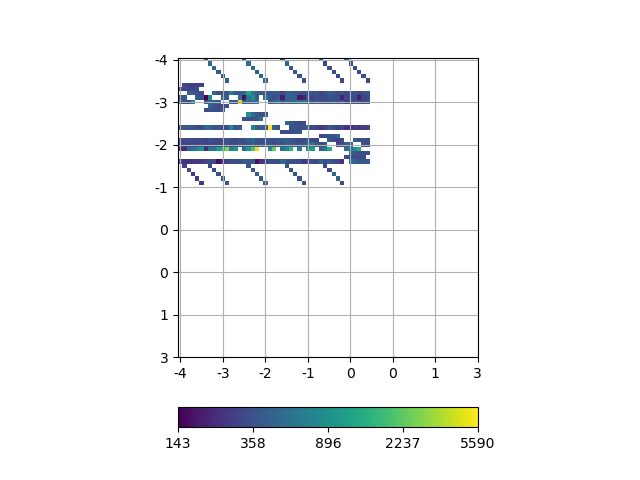

In [7]:
saint_data = pg.load('saintsmology_corrected.sgt')
print(saint_data)
saint_data.sortSensorsX()
tt.showVA(saint_data, usePos=True)

In [5]:
saint_data = pg.load('saintsmology_corrected.sgt')

print(saint_data)

# removing invalid data
saint_data.markInvalid(saint_data("t") <= 0)
saint_data.removeInvalid()

print(saint_data)

Data: Sensors: 75 data: 428, nonzero entries: ['g', 's', 't', 'valid']
Data: Sensors: 75 data: 428, nonzero entries: ['g', 's', 't', 'valid']


In [ ]:
pyvista = pg.optImport("pyvista")

x = np.arange(-6, 5, 0.20)
y = np.arange(-6, 5, 0.20)
z = np.arange(-2.5, 0.1, 0.4)

mesh = mt.createMesh3D(x=x, y=y, z=z)
mesh.createSecondaryNodes(1)


vel3 = np.zeros(len(pg.z(mesh.cellCenters())))

pg_z = pg.z(mesh.cellCenters())
pg_x = pg.x(mesh.cellCenters())
pg_y = pg.y(mesh.cellCenters())

for i, [jx, jy, jz] in enumerate(zip(pg_x, pg_y, pg_z)):
    if (jz >= -0.4) and (jz <= 0):
        vel3[i] = 100.0

    if jz >= -1.0 and jz < -0.4:
        vel3[i] = 200.0

    if jz < -1.0:
        vel3[i] = 300.0

# pg.show(mesh, vel3, showMesh=True, alpha=0.8)
pg.show(mesh, vel3, label=pg.utils.unit("vel"), showMesh=True, alpha=1)
mesh.addData("Velocity", vel3)

In [32]:
all_points = []

for x, y in stations:
    all_points.append([x, y, 0.])
for x, y in sources:
    all_points.append([x, y, 0.])

scheme = pg.physics.traveltime.createRAData(all_points)

mgr = TravelTimeManager()
plotter, _ = pg.show(mesh, style='wireframe', line_width=0.1,
                          hold=True)

drawSensors(plotter, all_points[0:45], diam=0.2, color='blue') # 45 because of 45 stations
drawSensors(plotter, all_points[45:], diam=0.2, color='red') # remaining are shots  
plotter.show()

Widget(value='<iframe src="http://localhost:61865/index.html?ui=P_0x3182191c0_3&reconnect=auto" class="pyvista…

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x412c99ca0>)

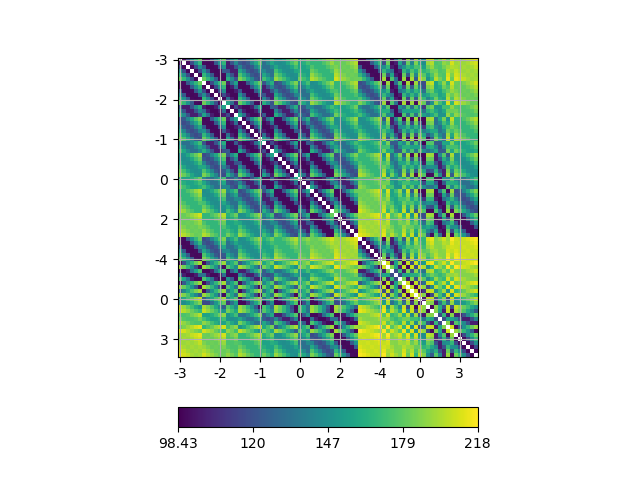

In [48]:
tt.showVA(data, usePos=True)

In [49]:
vest = mgr.invert(data,
                  mesh=mesh,
                  verbose=True,
                  maxIter=50)

21/11/25 - 16:14:41 - pyGIMLi - ERROR - <class 'pygimli.physics.traveltime.TravelTimeManager.TravelTimeManager'>.checkError(TravelTimeManager.py:105)
DataContainer has no "err" values. Fallback to 3%
21/11/25 - 16:14:42 - pyGIMLi - WARNING - Mesh already contains secondary nodes. Not adding any more.


min/max(dweight) = 841.643/6666.67
fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x3436ea110>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 0.005/0.04
min/max (error): 3%/3%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
min/max(dweight) = 841.643/6666.67
Building constraints matrix
constraint matrix of size(nBounds x nModel) 48924 x 17496
check Jacobian: wrong dimensions: (0x0) should be (5550x17496)  force: 1
jacobian size invalid, forced recalc: 1
Calculating Jacobian matrix (forced=1)...... inv.iter 0 ... chi² =  796.12
--------------------------------------------------------------------------------
inv.iter 1 ... 119.437 s
min data = 0.005 max data = 0.0396051 (5550)
min error = 0.03 max error = 0.03 (5550)
min response = 0.001 max response = 0.00450957 (5550)
calc without reference model
0: rms/rrms(data, response) = 0.020

In [50]:
ax, _ = pg.show(mesh, alpha=0., hold=True, colorBar=False)
drawSlice(ax,mesh,normal=[1,0,0], data=pg.abs(vest), label="velocity")
drawSlice(ax,mesh,normal=[0,1,0], data=pg.abs(vest), label="velocity")
ax.show()

Widget(value='<iframe src="http://localhost:61865/index.html?ui=P_0x40dc18c20_4&reconnect=auto" class="pyvista…